In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import jv
auev=27.2114
cau=137.036
nnm=18.8973


In [3]:
########### PART I ###########

def kronecker_delta(i, j):
    return int(i == j)

def Lorentzian(e,e0,gamma):
    return 1/(np.pi*gamma*(1+((e-e0)/gamma)**2))

def Pl_PINEM(beta,l):
    return jv(l,2*beta)**2

def fln2(l,n,b0,state,av):
    if n<np.max([0,-l]):
        return 0
    ff=np.sum([(-b0**2)**np/(math.factorial(np)*math.factorial(l+np)*math.factorial(n-np)) for np in range(int(np.max([0,-l])),n+1)])

    ff=np.abs(ff*np.exp(-b0**2/2)*math.sqrt(math.factorial(n+l)*math.factorial(n))*(-b0)**l)**2
    
    if state=='Fock':
        return kronecker_delta(n+l,av)*ff
    
    if state=='Thermal':
        return (1-np.exp(-av))*np.exp(-(n+l)*av)*ff
    
def Pl_QPINEM(l,b0,state,av,nmax):
    return np.sum([fln2(l,n,b0,state,av) for n in range(0,nmax+1)])
    
def Spectrum(type,enmin,enmax,nen,gamma,beta,b0,state,av,nmax,lmax):
    
    enTab=np.linspace(enmin,enmax,nen)

    if type=='PINEM':
        return np.array([np.sum([Pl_PINEM(beta,l)*Lorentzian(en,-l,gamma) for l in range(-lmax,lmax+1)]) for en in enTab])

    if type=='QPINEM':
        return np.array([np.sum([Pl_QPINEM(l,b0,state,av,nmax)*Lorentzian(en,-l,gamma) for l in range(-lmax,lmax+1)]) for en in enTab])

    raise ValueError("Unknown type: {}".format(type))

In [45]:
enmin=-10
enmax=10
nen=200

gamma=0.25
av=0 #Not needed for classical PINEM
b0=1.5 ##Not needed for classical PINEM
state='null' #Not needed for classical PINEM
nmax=10 #Not needed for classical PINEM

lmax=10 

type='PINEM'  # Selecting clasical PINEM
betaTab=[0,0.5,1.3,3]

enTab=np.linspace(enmin,enmax,nen)
spectra= [Spectrum(type,enmin,enmax,nen,gamma,beta,b0,state,av,nmax,lmax) for beta in betaTab]

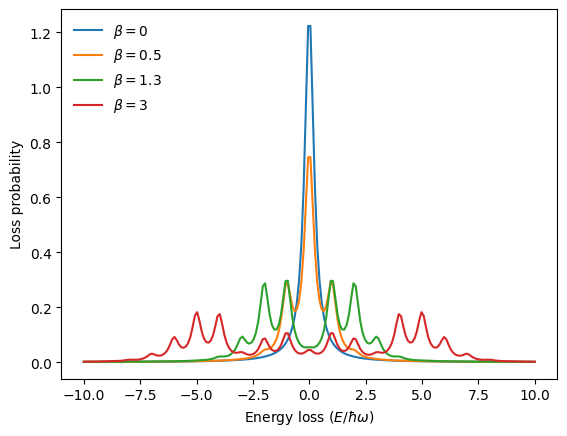

In [42]:
#Classical PINEM spectra


[plt.plot(enTab, spectra[i], label=r'$\beta=$'+str(betaTab[i])) for i in range(len(betaTab))]
plt.xlabel(r'Energy loss $(E/\hbar \omega)$')
plt.ylabel('Loss probability')
plt.legend(loc='upper left',fontsize=10,frameon=False)


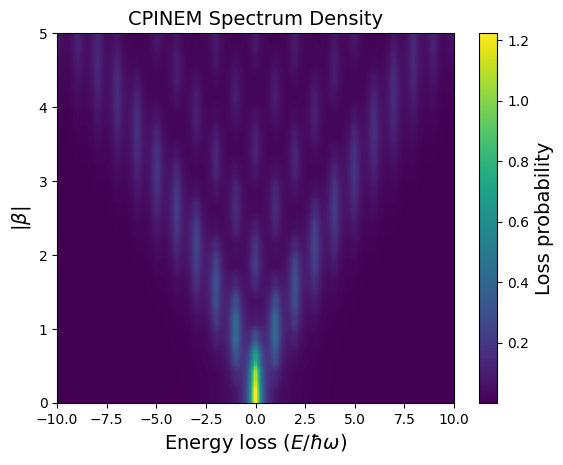

In [43]:
#Density plot for classical PINEM spectra

enmin=-10
enmax=10
nen=200

gamma=0.25
av=0 #Not needed for classical PINEM
b0=1.5 ##Not needed for classical PINEM
state='null' #Not needed for classical PINEM
nmax=10 #Not needed for classical PINEM
lmax=10 #Not needed for classical PINEM

type='PINEM'  #Selecting clasical PINEM

betamin=0
betamax=5
nbeta=20
betaTab=np.linspace(betamin, betamax,nbeta)
enTab=np.linspace(enmin,enmax,nen)
spectra_dens= [Spectrum(type,enmin,enmax,nen,gamma,beta,b0,state,av,nmax,lmax) for beta in betaTab]


plt.imshow(spectra_dens, aspect='auto', origin='lower',extent=[enmin, enmax, betamin, betamax], cmap='viridis')
cbar = plt.colorbar(label='Loss probability')
cbar.set_label('Loss probability', fontsize=14)
plt.xlabel('Energy loss $(E/\hbar \omega)$',fontsize=14)
plt.ylabel(r'$|\beta|$',fontsize=14)
plt.title('CPINEM Spectrum Density', fontsize=14)
plt.show()

In [91]:
#Density plot for classical QPINEM spectra

###### Fock state QPINEM spectra ########

enmin=-10
enmax=10
nen=200

gamma=0.25
avTab=[0,1,20]
b0Tab=np.array([1e-5,0.5,1.3,3])/np.sqrt(avTab[2])
print(b0Tab)
state='Fock'
nmax=40
lmax=10 

type='QPINEM'  # Selecting QPINEM

beta=0  # Not needed for QPINEM

enTab=np.linspace(enmin,enmax,nen)
spectra_fock= np.array([[Spectrum(type,enmin,enmax,nen,gamma,beta,b0,state,av,nmax,lmax) for b0 in b0Tab] for av in avTab])


[2.23606798e-06 1.11803399e-01 2.90688837e-01 6.70820393e-01]


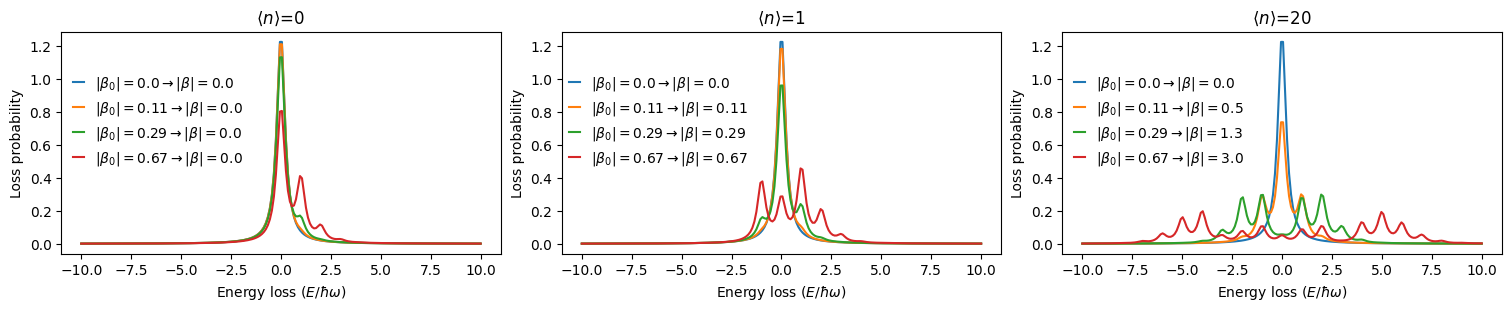

In [72]:
plots, axes = plt.subplots(1, len(avTab), constrained_layout=True,figsize=(15, 3))


for j in range(len(avTab)):
    axes[j].set_xlabel(r'Energy loss $(E/\hbar \omega)$')
    axes[j].set_ylabel(r'Loss probability')
    axes[j].set_title(r'$\langle n\rangle$='+str(avTab[j]))
    for i in range(len(b0Tab)):
        axes[j].plot(enTab,spectra_fock[j][i],label=r'$|\beta_0|=$'+str(round(b0Tab[i],2))+r'$\rightarrow |\beta|=$'+str(round(np.sqrt(avTab[j])*b0Tab[i],2)))
    axes[j].legend(loc='center',bbox_to_anchor=(0.22, 0.6),columnspacing=0.6,handlelength=0.8,ncol=1, fontsize=10,frameon=False)

In [ ]:
#Comparison of QPINEM and PINEM spectra

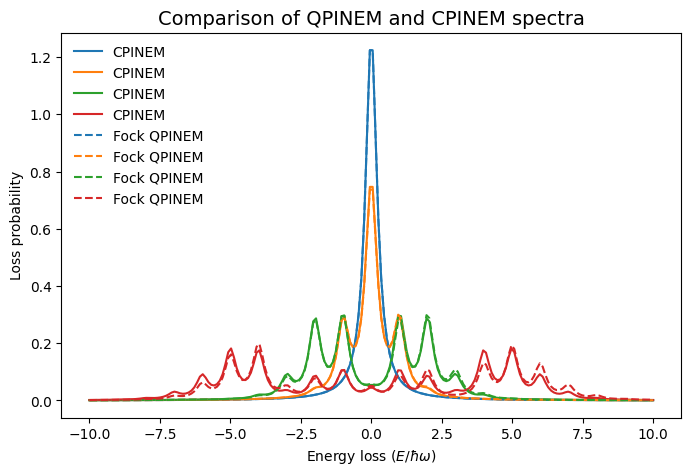

In [73]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(8, 5))
plt.title('Comparison of QPINEM and CPINEM spectra', fontsize=14)
[plt.plot(enTab, spectra[i], color=colors[i],label='CPINEM') for i in range(len(betaTab))]
[plt.plot(enTab,spectra_fock[-1][i],label=r'Fock QPINEM',color=colors[i],linestyle='dashed') for i in range(len(b0Tab))]
plt.xlabel(r'Energy loss $(E/\hbar \omega)$')
plt.ylabel('Loss probability')
plt.legend(loc='upper left',fontsize=10,frameon=False)

In [92]:
#Density plot for classical QPINEM spectra

###### Thermal state QPINEM spectra ########

enmin=-10
enmax=10
nen=200

gamma=0.25
thTab=np.array([100,0.7,0.0485]) #theta in a thermal state is connected to the average <n>=1/(exp(theta)-1)
avTab=1/(np.exp(thTab)-1)
b0Tab=np.array([1e-5,0.5,1.3,3])/np.sqrt(avTab[2])
print(b0Tab)
state='Thermal'
nmax=40
lmax=10 

type='QPINEM'  # Selecting QPINEM

beta=0  # Not needed for QPINEM

enTab=np.linspace(enmin,enmax,nen)
spectra_thermal= np.array([[Spectrum(type,enmin,enmax,nen,gamma,beta,b0,state,th,nmax,lmax) for b0 in b0Tab] for th in thTab])

[2.22924588e-06 1.11462294e-01 2.89801964e-01 6.68773763e-01]


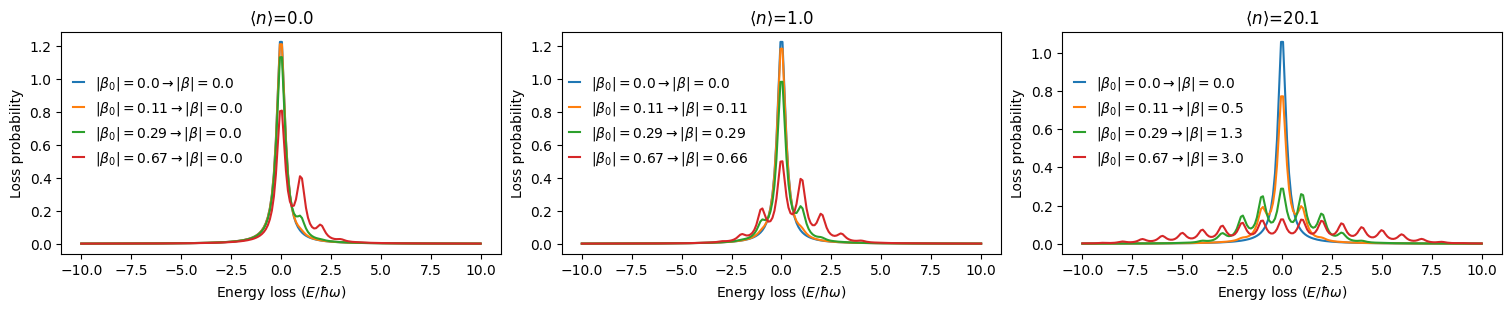

In [89]:
plots, axes = plt.subplots(1, len(thTab), constrained_layout=True,figsize=(15, 3))


for j in range(len(thTab)):
    axes[j].set_xlabel(r'Energy loss $(E/\hbar \omega)$')
    axes[j].set_ylabel(r'Loss probability')
    axes[j].set_title(r'$\langle n\rangle$='+str(round(avTab[j],1)))
    for i in range(len(b0Tab)):
        axes[j].plot(enTab,spectra_thermal[j][i],label=r'$|\beta_0|=$'+str(round(b0Tab[i],2))+r'$\rightarrow |\beta|=$'+str(round(np.sqrt(avTab[j])*b0Tab[i],2)))
    axes[j].legend(loc='center',bbox_to_anchor=(0.22, 0.6),columnspacing=0.6,handlelength=0.8,ncol=1, fontsize=10,frameon=False)

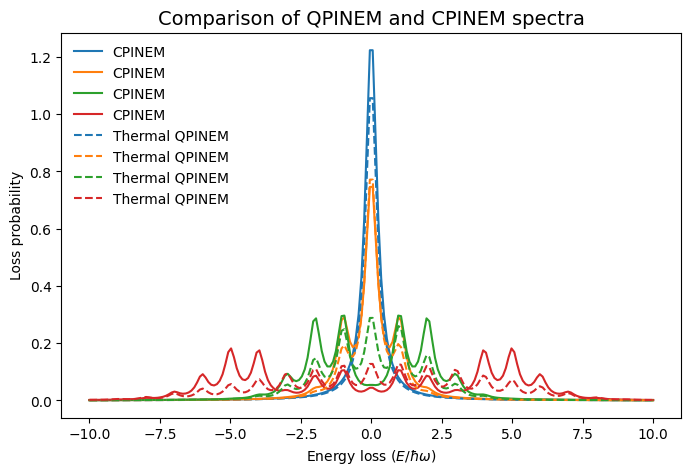

In [90]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(8, 5))
plt.title('Comparison of QPINEM and CPINEM spectra', fontsize=14)
[plt.plot(enTab, spectra[i], color=colors[i],label='CPINEM') for i in range(len(betaTab))]
[plt.plot(enTab,spectra_thermal[-1][i],label=r'Thermal QPINEM',color=colors[i],linestyle='dashed') for i in range(len(b0Tab))]
plt.xlabel(r'Energy loss $(E/\hbar \omega)$')
plt.ylabel('Loss probability')
plt.legend(loc='upper left',fontsize=10,frameon=False)

In [133]:
######## II PART #########

########## Code to compute the photonic Wigner function from the \rho_nn' ##########

import numpy as np
from scipy.special import eval_genlaguerre


#rhop must be a 2D numpy array where rhop[n,np] is the matrix element <n|rho_p|np>
def PhotonicWignerFunction(rhop, ReAlpha, ImAlpha):
    alpha = ReAlpha + 1j * ImAlpha
    A = alpha
    B = 4 * abs(A)**2
    out = 0j
    maxN = len(rhop)

    for m in range(maxN):
        # Diagonal term
        out += rhop[m, m] * ((-1)**m) * eval_genlaguerre(m, 0, B)

        for n in range(m + 1, maxN):
            # Off-diagonal term
            term = 2 * rhop[m, n] * ((-1)**m) * (2*A)**(n - m)
            term *= np.sqrt(math.factorial(m) / math.factorial(n)*1.0)
            term *= eval_genlaguerre(m, n - m, B)
            out += term

    result = 2 * np.real(out) * np.exp(-B / 2) / np.pi
    return result

#computes the purity of the state given by the density matrix rhop
#rhop must be a 2D numpy array where rhop[n,np] is the matrix element <n|rho_p|np>
#Purity is defined as Tr(rhop^2)
#It is a measure of how mixed the state is. A pure state has purity 1, while a mixed state has purity < 1.

def Purity(rhop):
    return np.trace(np.dot(rhop, rhop))

#########################

def CF(m,stw):
    return np.exp(-0.5*(m*stw)**2)

def rhonnp_Trace_Out(b0,stw,nmax):
    out=[]
    for n in range(nmax+1):
            out.append([np.exp(-b0**2)*np.conjugate(b0)**n *b0**npr * CF(npr-n,stw)/np.sqrt(1.0*math.factorial(n)*math.factorial(npr)) for npr in range(nmax+1)])
    return np.array(out)


In [130]:
### Light emitted by tracing out the electron ####

re_alpha_tab=np.linspace(-5,5,100)
im_alpha_tab=np.linspace(-5,5,100)

stwTab=[0,0.1,1,5]
b0=2
nmax=14

RA, IA = np.meshgrid(re_alpha_tab,im_alpha_tab)
PWF_Tab = [PhotonicWignerFunction(rhonnp_Trace_Out(b0,stwTab[i],nmax),RA,IA) for i in range(len(stwTab))]


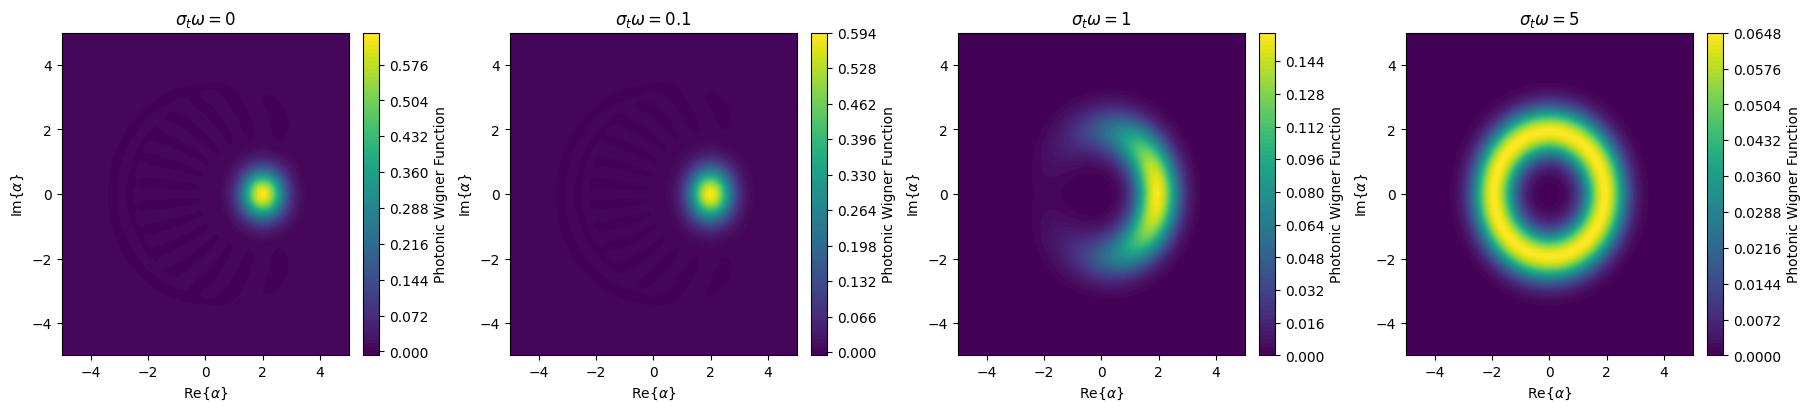

In [131]:
fig, axes = plt.subplots(1,len(stwTab), constrained_layout=True,figsize=(18, 4))

for i in range(len(stwTab)):
    axes[i].set_xlabel(r'Re{$\alpha$}')
    axes[i].set_ylabel(r'Im{$\alpha$}')
    axes[i].set_title(r'$\sigma_t\omega=$'+str(stwTab[i]))
    c1=axes[i].contourf(RA,IA,PWF_Tab[i],levels=100,cmap='viridis')
    fig.colorbar(c1, ax=axes[i], label=r'Photonic Wigner Function')

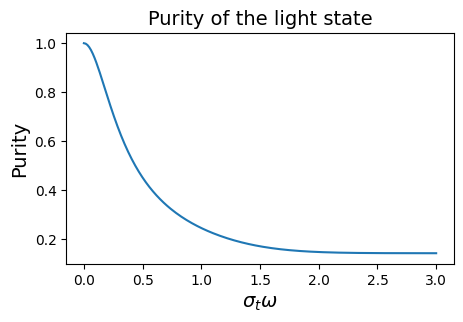

In [140]:
### Computing the light-state purity ###

stwTab=np.linspace(0,3,200)
b0=2
nmax=14

purity_values = [Purity(rhonnp_Trace_Out(b0, stw, nmax)) for stw in stwTab]
plt.figure(figsize=(5, 3))
plt.title('Purity of the light state', fontsize=14)
plt.xlabel(r'$\sigma_t\omega$',fontsize=14)
plt.ylabel('Purity',fontsize=14)
plt.plot(stwTab, purity_values, label='Purity of the state')    

In [159]:
### Light emitted when post-selecting the final energy of a previously modulated PINEM electron ####
### Here the electron is assumed to have been measured in the sideband s ###

def rhonnp_Post_PINEM(b0,nmax,b,s):
    out = []
    for n in range(nmax+1):
        out.append(np.exp(-b0**2/2)*np.conjugate(b0)**n/np.sqrt(1.0*math.factorial(n))*jv(n+s,2*b))
    out=np.array(out)/np.linalg.norm(out)
    return np.outer(out,out)

In [189]:
### Light emitted by tracing out the electron ####

re_alpha_tab=np.linspace(-5,5,100)
im_alpha_tab=np.linspace(-5,5,100)

bTab=[1,5,10]
sTab=[-5,5,10]
b0=2
nmax=20

RA, IA = np.meshgrid(re_alpha_tab,im_alpha_tab)
PWF_Tab = [[PhotonicWignerFunction(rhonnp_Post_PINEM(b0,nmax,b,s),RA,IA) for b in bTab] for s in sTab]

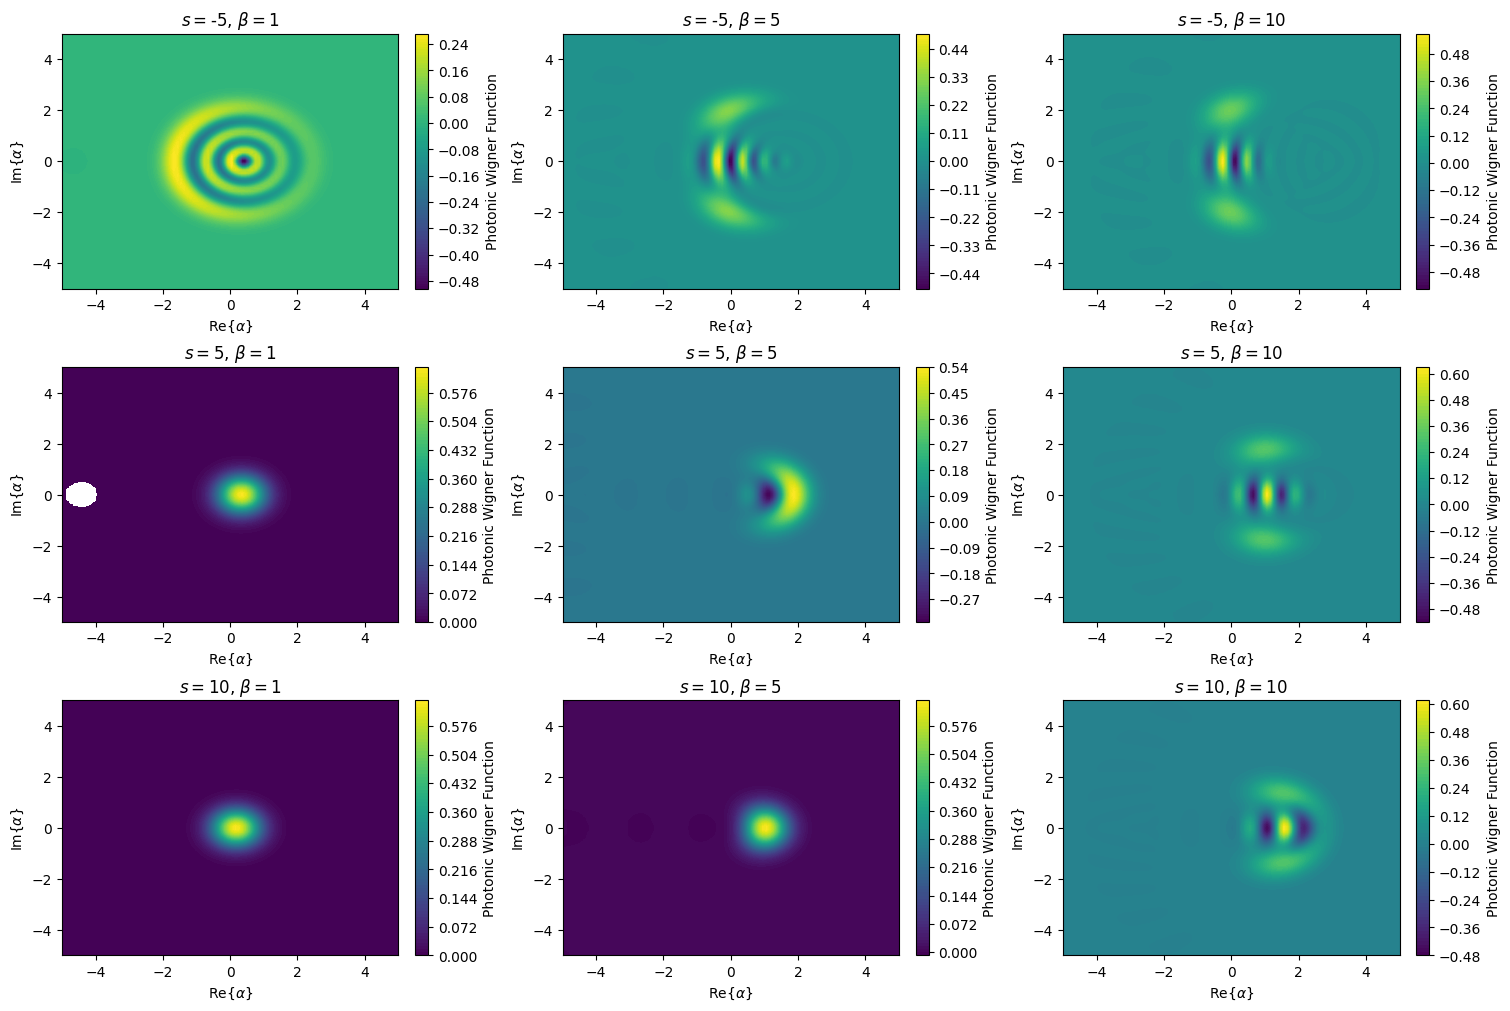

In [191]:
fig, axes = plt.subplots(len(sTab),len(bTab), constrained_layout=True,figsize=(15, 10))

for i in range(len(sTab)):
    for j in range(len(bTab)):
        axes[i,j].set_xlabel(r'Re{$\alpha$}')
        axes[i,j].set_ylabel(r'Im{$\alpha$}')
        axes[i,j].set_title(r'$s=$'+str(sTab[i])+r', $\beta=$'+str(bTab[j]))
        c1=axes[i,j].contourf(RA,IA,PWF_Tab[i][j],levels=100,cmap='viridis')
        fig.colorbar(c1, ax=axes[i,j], label=r'Photonic Wigner Function')